In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

In [ ]:
# Relevant Project Paths:
PROJ_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJ_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
raw_data_file_name = 'term-deposit-marketing-2020.csv'
RAW_DATA_PATH = RAW_DATA_DIR / raw_data_file_name

data = pd.read_csv(RAW_DATA_PATH) #Make sure this is the data post split and imputation

<h3>Feature Selection and Engineering

<h4>Categorical Feature Selection

In [9]:
# 1. Using chi-squared values to test if features and the target are independent.

# Null hypothesis (H0): Features and the target are independent.
from scipy.stats import chi2_contingency

cat_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month']
target_column = ['y']
alpha = 0.05

results = []

for col in cat_columns:
    table = pd.crosstab(data[col], data[target_column[0]])
    chi2, p, dof, expected = chi2_contingency(table)

    h0_rejected = p < alpha

    results.append({
        "feature": col,
        "chi_square": chi2,
        "p_value": p,
        "degrees_of_freedom": dof,
        "H0_rejected": "yes" if h0_rejected else "no"
    })

chi2_results = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
chi2_results


,feature,chi_square,p_value,degrees_of_freedom,H0_rejected
0,month,1523.706662,0.000000e+00,10,yes
1,contact,323.007275,7.242047e-71,2,yes
2,day,418.635958,4.733110e-70,30,yes
3,marital,135.898096,3.091031e-30,2,yes
4,housing,117.669421,2.048343e-27,1,yes
5,job,149.750422,1.676135e-26,11,yes
6,education,96.674415,8.061911e-21,3,yes
7,loan,38.196872,6.395487e-10,1,yes
8,default,1.545943,2.137353e-01,1,no


In [ ]:
# - If HO is rejected (p < 0.05), it means that there is plausibility that there is a dependence of 'y' on the feature column in question. 

# - Only 'default' appears to show independence. (p > 0.05)

In [11]:
# 2. Using Cramers V to find the strength of any association

# Use existing `cat_columns` and target from the notebook
target = target_column[0]  # 'y'

def cramers_v(x, y):
    table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, c = table.shape
    denom = n * (min(r, c) - 1)
    return np.sqrt(chi2 / denom) if denom > 0 else np.nan

cramers_v_results = pd.DataFrame(
    [{"feature": col, "cramers_v": cramers_v(data[col], data[target])} for col in cat_columns]
).sort_values("cramers_v", ascending=False).reset_index(drop=True)

cramers_v_results

,feature,cramers_v
0,month,0.195173
1,day,0.102303
2,contact,0.089862
3,job,0.061186
4,marital,0.058288
5,housing,0.054238
6,education,0.049162
7,loan,0.030902
8,default,0.006217


In [12]:
# - Strangely, 'month' and 'day' appear to show the strongest association with the target.
# - These are cyclical features. What if we try cyclical encoding during feature engineering for these columns?

In [14]:
# 3. Mutual Information:

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

# Reuse existing categorical column list from previous cells
X_cat = X[cat_columns]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_encoded = encoder.fit_transform(X_cat)

mi_scores = mutual_info_classif(
    X_encoded,
    y,
    discrete_features=True,
    random_state=13
)

mi_table = pd.DataFrame({
    "feature": cat_columns,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False).reset_index(drop=True)

mi_table


,feature,mutual_information
0,month,0.011453
1,day,0.004773
2,contact,0.004449
3,job,0.001720
4,marital,0.001650
5,housing,0.001449
6,education,0.001178
7,loan,0.000514
8,default,0.000023


In [16]:
# - Highest MI scores are for month and day...
# - It seems like exlcuding these would be un-wise.
# - Will make sure to use cyclical encoding rather than ordinal (false distance introduction) or one hot encoding (high dimensionality).

# - 'default' appears to be something that should be removed.

<h4>Numerical Feature Selection

In [17]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [18]:
numeric_cols = ['age','balance','duration']

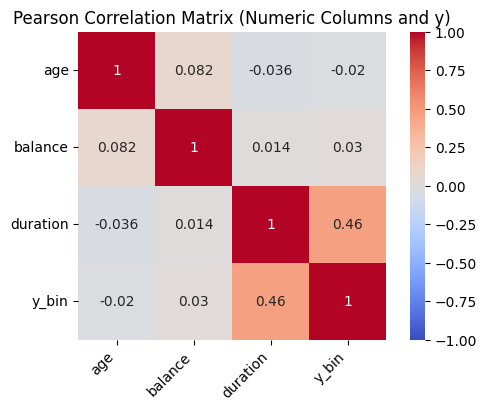

In [20]:
import seaborn as sns

import matplotlib.pyplot as plt
corr_df = data[numeric_cols].copy()
corr_df["y_bin"] = (y == "yes").astype(int)

corr_matrix = corr_df.corr(method="pearson")

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Pearson Correlation Matrix (Numeric Columns and y)")
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha="right")
plt.show()

In [21]:
# - The matrix shows that 'duration' has the highest correlation with y compared to the other numeric columns, and by some margin too...

Based on the analysis so far it seems like the features to remove are:
- Numerical: 'age', 'balance' 
- Categorical: 'default', 'loan', 'education'

If we carry out feature engineering now e.g. encoding etc, will any of the introduced features from encoding show up as poorly useful features using some of the feature selection techniques? It seems like it would be best to remove these features now due to the possible introduction of lots of additional features from high cardinality features.